# Notebook 03 — Behavioural Features from User Logs

**Source files:** `user_logs.csv` (392M rows, pre-Feb 2017) + `user_logs_v2.csv` (18M rows, Mar 2017) — UNION ALL via DuckDB (410M rows total)  
**Label file:** `train_v2.csv` (March 2017 churn labels, 970,960 customers)  
**Key column:** `msno` (not `customer_id`)  
**Snapshot date:** `2017-03-31` — used to compute `days_since_last_log` in Python after SQL aggregation  
**Note:** `date` column is stored as YYYYMMDD integer throughout

## Section 1 — Load Data & Run SQL Query

In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT    = Path("..").resolve()
DATA    = ROOT / "data"
OUTPUTS = ROOT / "outputs"
QUERIES = ROOT / "queries"
OUTPUTS.mkdir(exist_ok=True)

SNAPSHOT_DATE = pd.Timestamp("2017-03-31")

print(f"Project root : {ROOT}")
print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

Project root : C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction
Snapshot date: 2017-03-31


In [2]:
# Use a disk-backed DuckDB database so it can spill to disk when RAM is tight
db_path = str(OUTPUTS / "tmp_duckdb.db")
con = duckdb.connect(db_path)
con.execute("SET threads=2")
con.execute("SET preserve_insertion_order=false")

con.execute(f"""
    CREATE OR REPLACE TABLE train_labels AS
    SELECT * FROM read_csv_auto('{DATA}/train_v2.csv')
""")

lbl_total = con.execute("SELECT COUNT(*) FROM train_labels").fetchone()[0]
print(f"train_labels : {lbl_total:,} rows  (train_v2.csv — March 2017)")
print()
print("Strategy: aggregate each file separately (memory-safe), combine in Python.")
print("  user_logs.csv    — 392M rows, pre-Feb 2017")
print("  user_logs_v2.csv —  18M rows, Mar 2017  (no date overlap with v1)")
print("  Note: one row per (msno, date) in user_logs, so COUNT(*) == active_days")

train_labels : 970,960 rows  (train_v2.csv — March 2017)

Strategy: aggregate each file separately (memory-safe), combine in Python.
  user_logs.csv    — 392M rows, pre-Feb 2017
  user_logs_v2.csv —  18M rows, Mar 2017  (no date overlap with v1)
  Note: one row per (msno, date) in user_logs, so COUNT(*) == active_days


In [3]:
import time

# user_logs.csv has ~66k corrupt total_secs rows (61k negative, 4k > 1M seconds) —
# integer overflow artifacts in the original Kaggle data.  We filter to the physically
# possible range: 0 < total_secs <= 90000  (25 hours per day, very generous upper bound).
# This removes <0.02% of rows and eliminates the -9.2e15 / +9.2e15 sentinel values.

AGG_SQL = """
SELECT
    l.msno,
    SUM(CAST(l.total_secs AS DOUBLE))                                              AS sum_secs,
    COUNT(*)                                                                        AS n_rows,
    MAX(CAST(l.total_secs AS DOUBLE))                                               AS max_secs,
    SUM(CAST(l.num_25 + l.num_50 + l.num_75 + l.num_985 + l.num_100 AS DOUBLE))   AS total_songs,
    SUM(CAST(l.num_100 AS DOUBLE))                                                  AS sum_num100,
    SUM(CAST(l.num_25  AS DOUBLE))                                                  AS sum_num25,
    SUM(
        (l.num_unq * 1.0)
        / NULLIF(l.num_25 + l.num_50 + l.num_75 + l.num_985 + l.num_100, 0)
    )                                                                               AS sum_unq_ratio,
    COUNT(
        CASE WHEN l.num_25 + l.num_50 + l.num_75 + l.num_985 + l.num_100 > 0
             THEN 1 END
    )                                                                               AS n_unq_ratio_rows,
    MAX(l.date)                                                                     AS last_log_date,
    MIN(l.date)                                                                     AS first_log_date
FROM read_csv_auto('{filepath}') l
INNER JOIN train_labels lbl ON l.msno = lbl.msno
WHERE l.total_secs > 0 AND l.total_secs <= 90000
GROUP BY l.msno
"""

def agg_file(filepath, label):
    print(f"Aggregating {label} ...", end=" ", flush=True)
    t0 = time.time()
    df = con.execute(AGG_SQL.format(filepath=filepath)).df()
    print(f"{time.time()-t0:.1f}s  ->  {len(df):,} customers")
    return df

agg_v1 = agg_file(DATA / "user_logs.csv",    "user_logs.csv   (392M rows)")
agg_v2 = agg_file(DATA / "user_logs_v2.csv", "user_logs_v2.csv (18M rows)")

# ── Combine partial aggregations ─────────────────────────────────────────────
merged = agg_v1.merge(agg_v2, on="msno", how="outer", suffixes=("_v1", "_v2"))
fill_cols = ["sum_secs","n_rows","max_secs","total_songs","sum_num100",
             "sum_num25","sum_unq_ratio","n_unq_ratio_rows","last_log_date","first_log_date"]
for col in fill_cols:
    for s in ("_v1", "_v2"):
        merged[col+s] = merged[col+s].fillna(0)

log_features = pd.DataFrame()
log_features["msno"]               = merged["msno"]
log_features["total_secs"]         = merged["sum_secs_v1"]    + merged["sum_secs_v2"]
n_rows_total                        = merged["n_rows_v1"]      + merged["n_rows_v2"]
log_features["avg_daily_secs"]     = log_features["total_secs"] / n_rows_total.replace(0, np.nan)
log_features["max_daily_secs"]     = merged[["max_secs_v1","max_secs_v2"]].max(axis=1)
log_features["total_songs_played"] = merged["total_songs_v1"] + merged["total_songs_v2"]
total_songs_all                     = log_features["total_songs_played"].replace(0, np.nan)
log_features["completion_rate"]    = (merged["sum_num100_v1"] + merged["sum_num100_v2"]) / total_songs_all
log_features["skip_rate"]          = (merged["sum_num25_v1"]  + merged["sum_num25_v2"])  / total_songs_all
n_unq_denom                         = (merged["n_unq_ratio_rows_v1"] + merged["n_unq_ratio_rows_v2"]).replace(0, np.nan)
log_features["unique_songs_ratio"] = (merged["sum_unq_ratio_v1"] + merged["sum_unq_ratio_v2"]) / n_unq_denom
log_features["active_days"]        = (merged["n_rows_v1"] + merged["n_rows_v2"]).astype(int)
log_features["last_log_date"]      = merged[["last_log_date_v1","last_log_date_v2"]].max(axis=1).astype(int)
first_v1 = merged["first_log_date_v1"].replace(0, np.nan)
first_v2 = merged["first_log_date_v2"].replace(0, np.nan)
log_features["first_log_date"]     = pd.concat([first_v1, first_v2], axis=1).min(axis=1).astype("Int64")

# days_since_last_log — snapshot_date = 2017-03-31
log_features["days_since_last_log"] = (
    SNAPSHOT_DATE - pd.to_datetime(log_features["last_log_date"].astype(str), format="%Y%m%d")
).dt.days

train_v2 = pd.read_csv(DATA / "train_v2.csv")

print(f"\nFinal shape: {log_features.shape[0]:,} rows x {log_features.shape[1]} cols")
print(f"\nNull counts per column:")
nulls    = log_features.isnull().sum()
null_pct = (nulls / len(log_features) * 100).round(2)
print(pd.DataFrame({"nulls": nulls, "null_%": null_pct}).to_string())
print(f"\nSummary statistics:")
drop_cols = ["msno", "last_log_date", "first_log_date"]
print(log_features.drop(columns=drop_cols).describe().round(2).to_string())

Aggregating user_logs.csv   (392M rows) ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

91.0s  ->  850,295 customers
Aggregating user_logs_v2.csv (18M rows) ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

6.8s  ->  754,541 customers



Final shape: 855,159 rows x 12 cols

Null counts per column:
                     nulls  null_%
msno                     0     0.0
total_secs               0     0.0
avg_daily_secs           0     0.0
max_daily_secs           0     0.0
total_songs_played       0     0.0
completion_rate          0     0.0
skip_rate                0     0.0
unique_songs_ratio       0     0.0
active_days              0     0.0
last_log_date            0     0.0
first_log_date           0     0.0
days_since_last_log      0     0.0

Summary statistics:


        total_secs  avg_daily_secs  max_daily_secs  total_songs_played  completion_rate  skip_rate  unique_songs_ratio  active_days  days_since_last_log
count    855159.00       855159.00       855159.00           855159.00        855159.00  855159.00           855159.00    855159.00            855159.00
mean    2364595.39         6567.99        32060.24            11946.83             0.68       0.20                0.82       292.82                26.43
std     3255648.04         5322.74        19303.81            15352.00             0.20       0.15                0.12       232.38                90.88
min           0.08            0.08            0.08                1.00             0.00       0.00                0.00         1.00                 0.00
25%      359868.74         3435.85        18063.65             1991.00             0.58       0.10                0.76        85.00                 0.00
50%     1279611.95         5256.14        29633.27             6802.00            

## Section 2 — The Churn Signal: Engagement vs Churn

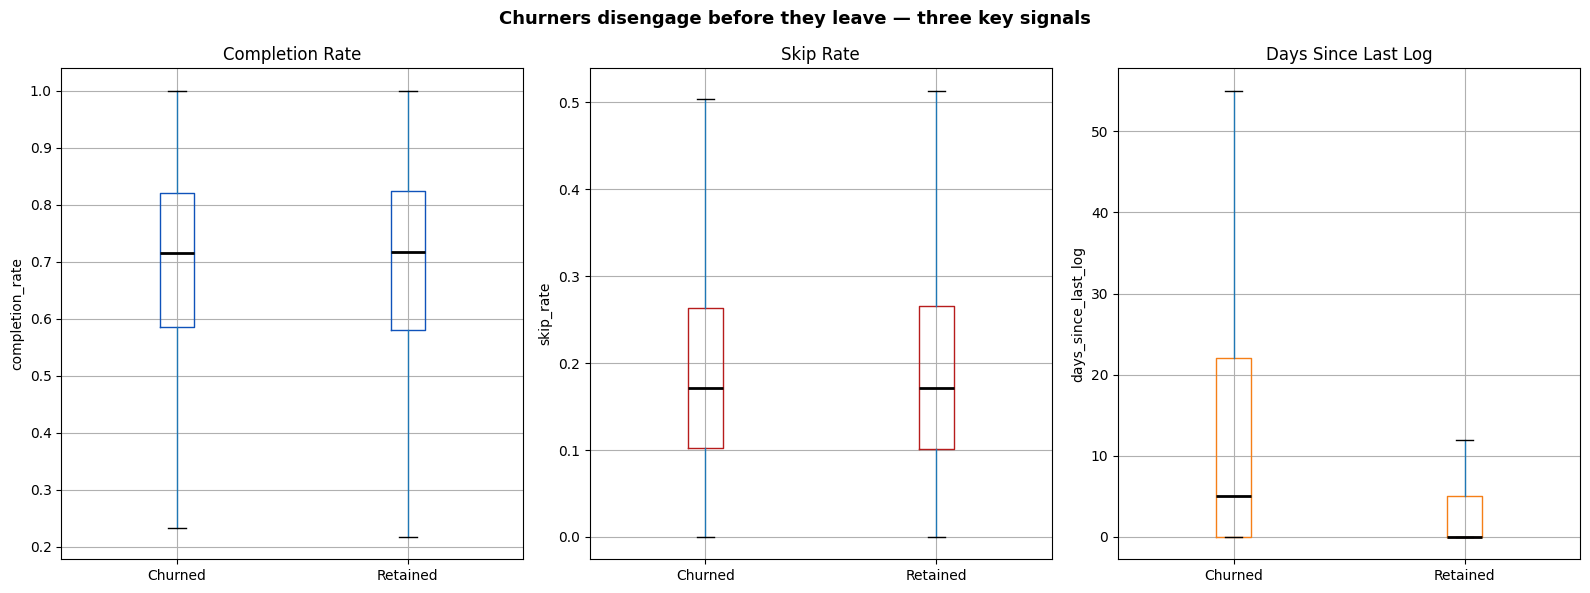

Saved: outputs/03_churn_engagement_signals.png

Median values by churn label:
             completion_rate  skip_rate  days_since_last_log
churn_label                                                 
Churned               0.7158     0.1711                  5.0
Retained              0.7172     0.1709                  0.0


In [4]:
df = log_features.merge(train_v2[["msno", "is_churn"]], on="msno", how="inner")
df["churn_label"] = df["is_churn"].map({0: "Retained", 1: "Churned"})

palette = {"Retained": "#1B5E20", "Churned": "#B71C1C"}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    "Churners disengage before they leave — three key signals",
    fontsize=13, fontweight="bold"
)

# Box plot 1: completion_rate
ax = axes[0]
df.boxplot(
    column="completion_rate", by="churn_label", ax=ax,
    boxprops=dict(color="#0F52BA"),
    medianprops=dict(color="black", linewidth=2),
    showfliers=False
)
ax.set_title("Completion Rate\n(fraction of songs fully played)")
ax.set_xlabel("")
ax.set_ylabel("completion_rate")
plt.sca(ax); plt.title("Completion Rate")

# Box plot 2: skip_rate
ax = axes[1]
df.boxplot(
    column="skip_rate", by="churn_label", ax=ax,
    boxprops=dict(color="#B71C1C"),
    medianprops=dict(color="black", linewidth=2),
    showfliers=False
)
ax.set_title("Skip Rate\n(fraction of songs abandoned early)")
ax.set_xlabel("")
ax.set_ylabel("skip_rate")
plt.sca(ax); plt.title("Skip Rate")

# Box plot 3: days_since_last_log
ax = axes[2]
df.boxplot(
    column="days_since_last_log", by="churn_label", ax=ax,
    boxprops=dict(color="#F57F17"),
    medianprops=dict(color="black", linewidth=2),
    showfliers=False
)
ax.set_title("Days Since Last Log\n(recency — higher = more dormant)")
ax.set_xlabel("")
ax.set_ylabel("days_since_last_log")
plt.sca(ax); plt.title("Days Since Last Log")

fig.suptitle("Churners disengage before they leave — three key signals",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "03_churn_engagement_signals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_churn_engagement_signals.png")

# Print median values per group for quick read
print("\nMedian values by churn label:")
print(df.groupby("churn_label")[["completion_rate", "skip_rate", "days_since_last_log"]]
      .median().round(4).to_string())

## Section 3 — Scatter: Completion Rate vs Avg Daily Listening Time

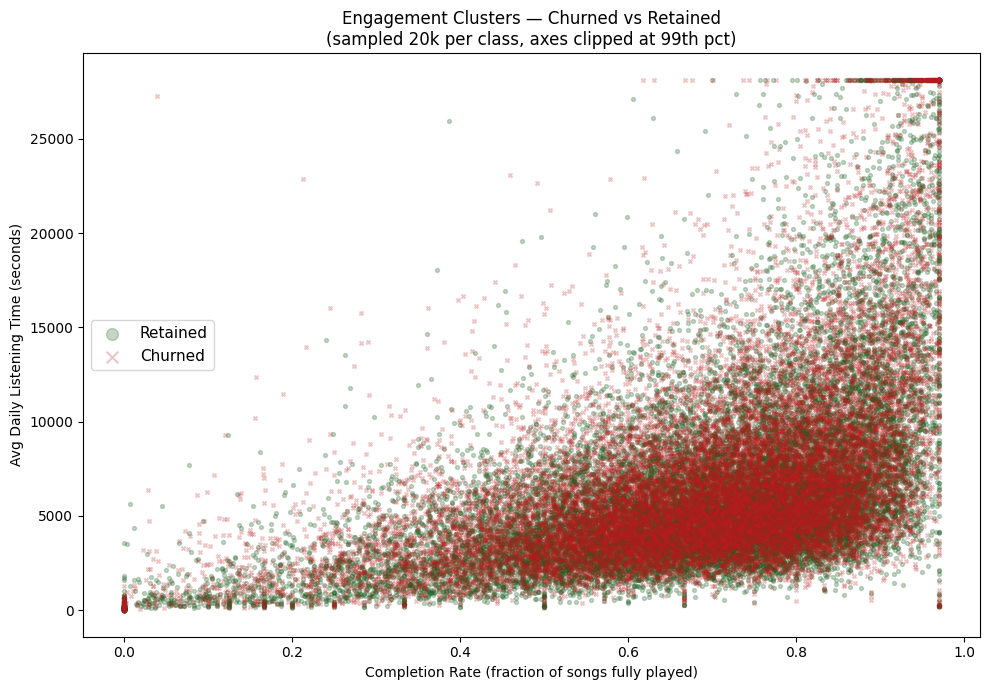

Saved: outputs/03_engagement_scatter.png


In [5]:
# Sample 20k points per class to keep the scatter readable
sample_retained = df[df["is_churn"] == 0].sample(n=min(20000, (df["is_churn"]==0).sum()), random_state=42)
sample_churned  = df[df["is_churn"] == 1].sample(n=min(20000, (df["is_churn"]==1).sum()), random_state=42)
plot_df = pd.concat([sample_retained, sample_churned])

# Cap axes at 99th percentile to avoid outlier-dominated plot
x_cap = df["completion_rate"].quantile(0.99)
y_cap = df["avg_daily_secs"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 7))
for label, color, marker in [("Retained", "#1B5E20", "o"), ("Churned", "#B71C1C", "x")]:
    sub = plot_df[plot_df["churn_label"] == label]
    ax.scatter(
        sub["completion_rate"].clip(upper=x_cap),
        sub["avg_daily_secs"].clip(upper=y_cap),
        c=color, label=label, alpha=0.25, s=8, marker=marker
    )

ax.set_xlabel("Completion Rate (fraction of songs fully played)")
ax.set_ylabel("Avg Daily Listening Time (seconds)")
ax.set_title("Engagement Clusters — Churned vs Retained\n(sampled 20k per class, axes clipped at 99th pct)")
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS / "03_engagement_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/03_engagement_scatter.png")

## Section 4 — Save

In [6]:
out_path = OUTPUTS / "log_features.parquet"
log_features.to_parquet(out_path, index=False)
print(f"Saved : {out_path}")
print(f"Shape : {log_features.shape[0]:,} rows x {log_features.shape[1]} cols")
print(f"Columns: {list(log_features.columns)}")

# Coverage check: how many of the 970,960 labelled customers have log data?
n_labelled  = len(train_v2)
n_with_logs = len(log_features)
n_no_logs   = n_labelled - n_with_logs
print(f"\nCoverage:")
print(f"  Labelled customers         : {n_labelled:,}")
print(f"  With log data (INNER JOIN) : {n_with_logs:,}  ({n_with_logs/n_labelled*100:.1f}%)")
print(f"  No log data at all         : {n_no_logs:,}  ({n_no_logs/n_labelled*100:.1f}%) — will be zero-filled in notebook 04")

Saved : C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\outputs\log_features.parquet
Shape : 855,159 rows x 12 cols
Columns: ['msno', 'total_secs', 'avg_daily_secs', 'max_daily_secs', 'total_songs_played', 'completion_rate', 'skip_rate', 'unique_songs_ratio', 'active_days', 'last_log_date', 'first_log_date', 'days_since_last_log']

Coverage:
  Labelled customers         : 970,960
  With log data (INNER JOIN) : 855,159  (88.1%)
  No log data at all         : 115,801  (11.9%) — will be zero-filled in notebook 04
